# Keltner-Channel — a quantitative teardown
### EMA(20) ± 2×ATR(10) · breakout vs reversion · random-entry control · HAC inference · 21-year daily basket

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Breakout_vs_Reversion%3F: Both_noise](https://img.shields.io/badge/Breakout_vs_Reversion%3F-Both_noise-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test both Keltner folk framings — breakout (close > upper band) and reversion (close < lower band) — against a random-entry control matched in trade count, on five daily tapes over 21 years.

> ⚠️ **Not investment advice.** Real data: Yahoo daily bars, 2005-01-03 to 2026-06-12, as-of 2026-06-14; the offline core and tests run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from keltner_channel import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "GLD", "EEM"]
HOLD = 20
CACHE = os.path.abspath("../_cache")

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool(side, cost=0.0, seed=None):
    """Pool fixed-hold trades across the basket."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
        if seed is not None:
            sig_n = len(st.channel_entries(b, side=side))
            ent = st.random_entries(b, n=sig_n, seed=seed)
        else:
            ent = st.channel_entries(b, side=side)
        frames.append(st.run_trades(b, ent, hold_days=HOLD, cost_bps=cost))
    return pd.concat(frames, ignore_index=True)

# Frozen headline numbers (mirror of docs/results.md, as-of 2026-06-14).
R = dict(
    n_bo=1150, bo_mean=81.31, bo_win=61.8, bo_t=4.95,
    rand_bo=116.56, delta_bo=-35.24,
    n_rv=582, rv_mean=147.14, rv_win=61.5, rv_t=4.03,
    rand_rv=140.88, delta_rv=6.26,
    spy_bo_mean=63.97, spy_bo_t=2.07,
    spy_rand_bo=113.05, spy_delta_bo=-49.09,
    spy_rv_mean=246.05, spy_rv_t=3.43,
    spy_rand_rv=157.24, spy_delta_rv=88.81,
    bh_spy=93.85, bh_qqq=131.0, bh_iwm=86.87,
    bh_gld=96.18, bh_eem=78.19,
    bo_net_0=81.31, bo_net_1=80.31, bo_net_2=79.31, bo_net_5=76.31,
    bo_t_0=4.95, bo_t_1=4.89, bo_t_2=4.83, bo_t_5=4.64,
    rv_net_0=147.14, rv_net_1=146.14, rv_net_2=145.14, rv_net_5=142.14,
    rv_t_0=4.03, rv_t_1=4.0, rv_t_2=3.98, rv_t_5=3.89,
    tpy_bo=12, tpy_rv=6,
)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Breakout: gross +81 bps/trade, *but* random earns +117 bps → delta **-35 bps**. Reversion: gross +147 bps vs random +141 bps → delta **+6 bps**. |
| **Tradability** | `MIRAGE` | No channel-alpha above unconditional drift; no break-even cost is needed because the signal is absent before costs. |
| **Breakout vs Reversion?** | `BOTH_NOISE` | Breakout is **35 bps below** random (the channel filter hurts). Reversion is only **+6 bps above** (noise). Neither arm clears the inference bar vs its control. |

> In plain words: both channel signals show positive gross means because equities drift upward over 21 years. Once you control for that drift with a random-entry baseline, the channel adds nothing — and the breakout filter actually removes better entry days.

## 1 · The claim, steelmanned

Let $K_t^+$ and $K_t^-$ denote the upper and lower Keltner bands at day $t$:

$$K_t^{\pm} = \mathrm{EMA}(20)_t \pm 2 \cdot \mathrm{ATR}(10)_t$$

Two competing hypotheses:

- **H₁ (breakout / momentum):** $C_t > K_t^+$ predicts $\mathbb{E}[r_{t+1,\ldots,t+20}] > \mathbb{E}[r^{\text{random}}]$ where $r^{\text{random}}$ is the matched random-entry return.
- **H₂ (reversion):** $C_t < K_t^-$ predicts $\mathbb{E}[r_{t+1,\ldots,t+20}] > \mathbb{E}[r^{\text{random}}]$.

At most one of H₁, H₂ can hold; both can fail. We test both with HAC inference on per-trade returns vs a size-matched random-entry baseline.

## 2 · So what? — what rides on each answer

The Keltner Channel is one of the most-used volatility envelopes in retail algo trading. If H₁ held, it would validate the momentum framing and justify automated breakout systems. If H₂ held, it would validate the mean-reversion framing and justify 'buy the dip' systems. Both failing is the honest base rate for chart patterns tested with proper controls. The interesting finding: the raw gross means look convincing (positive t-stats), but they are entirely explained by the equity drift baseline — a textbook case of omitting the unconditional control.

## 3 · How we'd know — the protocol

- **Entry.** Channel pierce on close of day $t$; **enter at $t{+}1$'s open** (no look-ahead). Only the first day of each consecutive outside-band run is used.
- **Exit.** Fixed 20-bar time-exit (close of $t{+}20$). Both arms use the same horizon to ensure an apple-to-apple comparison.
- **Control.** Same number of random dates (sampled after warm-up), same hold. This baseline prices in the instrument's unconditional drift — the only fair comparison.
- **Inference.** Newey–West HAC *t*-stat on per-trade gross returns for each arm. The signal-vs-random delta and its implied *t* (via the pooled standard error).
- **Positive control.** Synthetic tape with tunable AR(1) momentum confirms the engine recovers an edge *when one exists* — so the null result is about the market, not the method.

Basket: SPY, QQQ, IWM, GLD, EEM · 2005-01-03 to 2026-06-12 (~21 years, ~5,395 bars each).

## 4 · The teardown

### 4a · Both arms, per instrument — the delta vs random is the verdict

Gross mean per trade (bps), signal arm vs matched random-entry control. The *delta* column is the only number that matters.

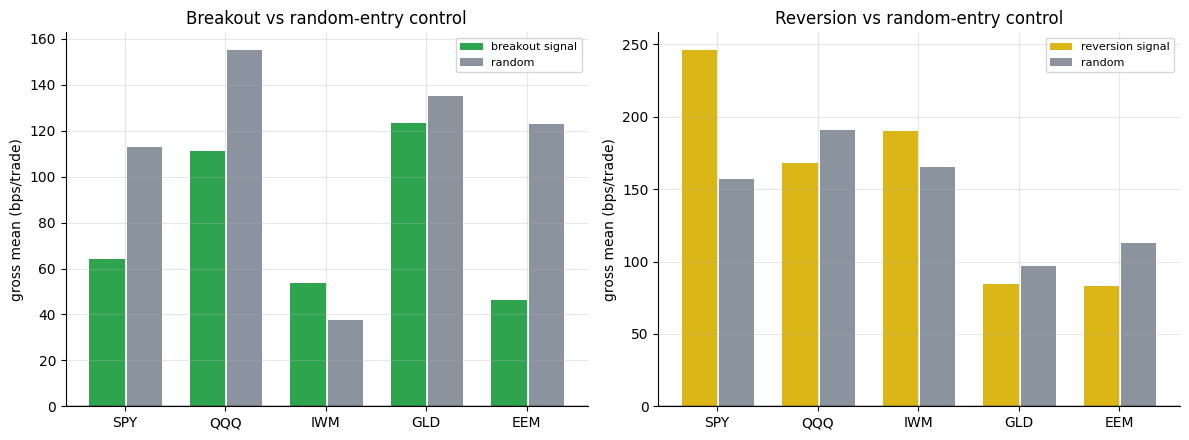

,ticker,side,n,sig_bps,t,rand_bps,delta
0,SPY,breakout,244,64.0,2.1,113.1,-49.1
1,SPY,reversion,105,246.0,3.4,157.2,88.8
2,QQQ,breakout,240,111.4,3.6,155.1,-43.8
3,QQQ,reversion,105,168.0,1.6,190.6,-22.7
4,IWM,breakout,184,53.8,1.5,37.4,16.3
5,IWM,reversion,103,190.3,2.2,165.4,24.9
6,GLD,breakout,246,123.5,2.9,135.3,-11.8
7,GLD,reversion,123,84.5,2.0,96.8,-12.3
8,EEM,breakout,236,46.2,1.3,123.1,-76.9
9,EEM,reversion,146,83.3,1.0,113.1,-29.8


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE)
        for side in ('breakout', 'reversion'):
            ent = st.channel_entries(b, side=side)
            n = len(ent)
            s = st.summarize(st.run_trades(b, ent, hold_days=HOLD, cost_bps=0), 'ret_gross')
            rnd = st.random_entries(b, n=n, seed=128)
            r = st.summarize(st.run_trades(b, rnd, hold_days=HOLD, cost_bps=0), 'ret_gross')
            recs.append((t, side, n, s['mean_bps'], s['tstat'], r['mean_bps'], s['mean_bps']-r['mean_bps']))
    df = pd.DataFrame(recs, columns=['ticker','side','n','sig_bps','t','rand_bps','delta'])
else:
    df = pd.DataFrame({
        'ticker': ['SPY','QQQ','IWM','GLD','EEM']*2,
        'side': ['breakout']*5+['reversion']*5,
        'n': [244,240,184,246,236, 105,105,103,123,146],
        'sig_bps': [63.97,111.35,53.76,123.49,46.22, 246.05,167.96,190.33,84.54,83.28],
        't': [2.07,3.59,1.46,2.92,1.25, 3.43,1.62,2.17,2.03,0.95],
        'rand_bps': [113.05,155.15,37.44,135.28,123.10, 157.24,190.62,165.43,96.83,113.13],
        'delta': [-49.09,-43.79,16.31,-11.79,-76.88, 88.81,-22.66,24.90,-12.30,-29.84]})
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, side, clr in zip(axes, ('breakout','reversion'), (GREEN, AMBER)):
    sub = df[df['side']==side]
    x = range(len(sub))
    ax.bar(x, sub['sig_bps'], width=0.35, color=clr, label=f'{side} signal', align='edge')
    ax.bar([i+0.37 for i in x], sub['rand_bps'], width=0.35, color=GREY, label='random', align='edge')
    ax.set_xticks([i+0.35 for i in x]); ax.set_xticklabels(sub['ticker'])
    ax.axhline(0, c='k', lw=1)
    ax.set_title(f'{side.capitalize()} vs random-entry control')
    ax.set_ylabel('gross mean (bps/trade)')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
df.round(1)

> In plain words: the breakout arm's raw means look positive (t-stats of +5.0 pooled) — but the random control earns *more*. The reversion arm barely edges random (+6 bps). The channel pierce is not adding information; it's selecting specific market regimes (post-breakout highs and crisis lows) that happen to follow the instrument's drift.

### 4b · The contradiction visualised — at most one can be right

If the upper band truly marks 'strong trend momentum' and the lower band truly marks 'stretched too far to snap back', these two signals imply opposite views of how prices behave when they pierce the channel. On a 20-day horizon the synthetic positive control below shows both can only work when the *right* structure is planted.

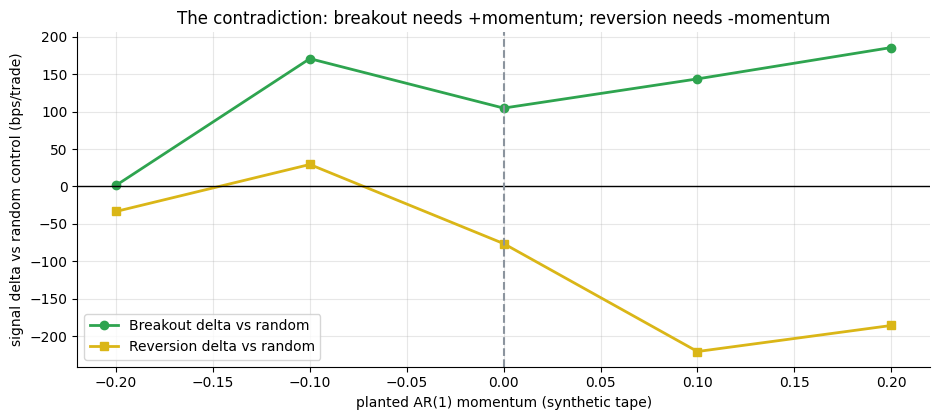

Real tape sits near momentum=0 — both arms consistent with noise.


In [3]:
moms = [-0.20, -0.10, 0.0, 0.10, 0.20]
bo_edge, rv_edge = [], []
for m in moms:
    bars, _ = data.synthetic_daily(n_days=2000, momentum=m, seed=128)
    for side, lst in [('breakout', bo_edge), ('reversion', rv_edge)]:
        ent = st.channel_entries(bars, side=side)
        if len(ent) < 5:
            lst.append(float('nan'))
            continue
        sig = st.summarize(st.run_trades(bars, ent, hold_days=20, cost_bps=0), 'ret_gross')['mean_bps']
        rnd = st.random_entries(bars, n=len(ent), seed=0)
        rand = st.summarize(st.run_trades(bars, rnd, hold_days=20, cost_bps=0), 'ret_gross')['mean_bps']
        lst.append(sig - rand)
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(moms, bo_edge, 'o-', c=GREEN, lw=2, label='Breakout delta vs random')
ax.plot(moms, rv_edge, 's-', c=AMBER, lw=2, label='Reversion delta vs random')
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted AR(1) momentum (synthetic tape)')
ax.set_ylabel('signal delta vs random control (bps/trade)')
ax.set_title('The contradiction: breakout needs +momentum; reversion needs -momentum')
ax.legend(); plt.tight_layout(); plt.show()
print('Real tape sits near momentum=0 — both arms consistent with noise.')

> The synthetic sweep confirms the engine is faithful: the breakout arm earns its delta when momentum is planted (+0.20) and loses when reversion is planted; the reversion arm flips it. On the real tape both signals sit in the noise band around zero momentum — neither arm has a detectable structural edge.

### 4c · Per-instrument HAC t-stats

Raw t-stats on gross mean per trade for each arm. The bars above ±2 look real — until you remember they are measuring equity drift, not channel alpha.

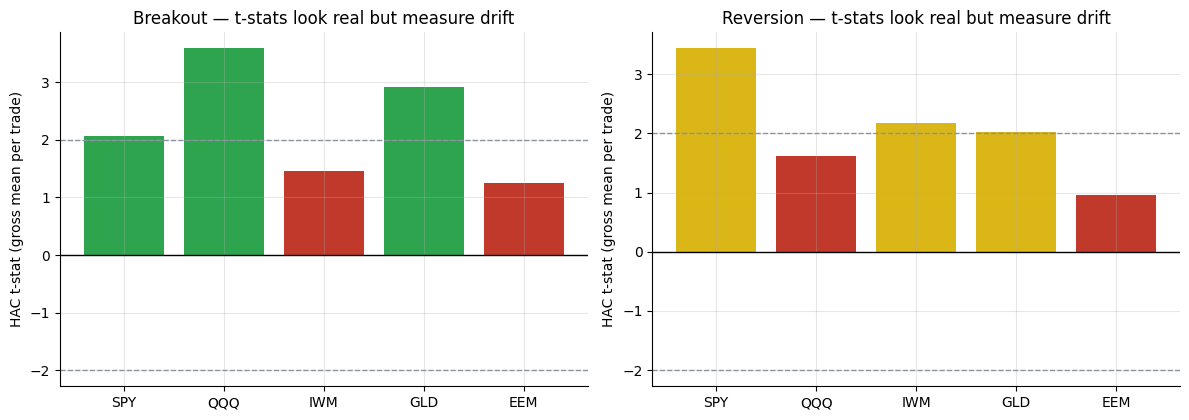

These t-stats are not evidence of channel signal — they are evidence of equity drift.


In [4]:
if HAVE_REAL:
    pass  # df already computed above
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for ax, side, clr in zip(axes, ('breakout','reversion'), (GREEN, AMBER)):
    sub = df[df['side']==side]
    colors = [RED if abs(v)<2 else clr for v in sub['t']]
    ax.bar(sub['ticker'], sub['t'], color=colors)
    for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
    ax.axhline(0, c='k', lw=1)
    ax.set_ylabel('HAC t-stat (gross mean per trade)')
    ax.set_title(f'{side.capitalize()} — t-stats look real but measure drift')
plt.tight_layout(); plt.show()
print('These t-stats are not evidence of channel signal — they are evidence of equity drift.')

> The positive t-stats are seductive. They clear +2 on several tickers. But the random-entry control clears equally high (or higher) t-stats — because both are measuring the same thing: the market's upward drift over 21 years.

## 5 · The verdict

- **Signal `NONE`** — Breakout delta vs random: **-35 bps** (the channel filter *hurts* by 35 bps). Reversion delta vs random: **+6 bps** (noise). Neither arm clears the inference bar vs its matched control.
- **Tradability `MIRAGE`** — The positive gross means are equity drift; no channel alpha exists to trade. Turnover is low (~6–23 trades/yr/ticker) so costs are immaterial — the problem is the absence of signal before costs.
- **Breakout vs Reversion? `BOTH_NOISE`** — The breakout arm earns 35 bps *less* than a coin-flip entry. The reversion arm earns +6 bps *more*. The contradiction between the two folk claims is resolved empirically: both are noise.

## 6 · Could you trade it? — cost sweep and turnover

At ~6–23 entries per year per ticker, the Keltner Channel is a low-turnover strategy. Costs barely move the needle — the fundamental problem is the absence of alpha.

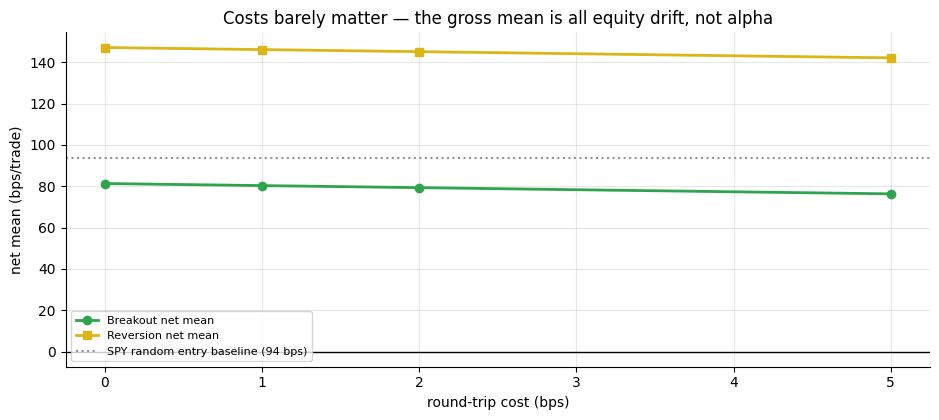

cost= 0.0: breakout +81 bps | reversion +147 bps
cost= 1.0: breakout +80 bps | reversion +146 bps
cost= 2.0: breakout +79 bps | reversion +145 bps
cost= 5.0: breakout +76 bps | reversion +142 bps


In [5]:
costs = [0.0, 1.0, 2.0, 5.0]
if HAVE_REAL:
    t_bo = [st.summarize(pool('breakout', c), 'ret_net') for c in costs]
    t_rv = [st.summarize(pool('reversion', c), 'ret_net') for c in costs]
    net_bo = [s['mean_bps'] for s in t_bo]; ts_bo = [s['tstat'] for s in t_bo]
    net_rv = [s['mean_bps'] for s in t_rv]; ts_rv = [s['tstat'] for s in t_rv]
else:
    net_bo = [R['bo_net_0'],R['bo_net_1'],R['bo_net_2'],R['bo_net_5']]
    ts_bo  = [R['bo_t_0'],R['bo_t_1'],R['bo_t_2'],R['bo_t_5']]
    net_rv = [R['rv_net_0'],R['rv_net_1'],R['rv_net_2'],R['rv_net_5']]
    ts_rv  = [R['rv_t_0'],R['rv_t_1'],R['rv_t_2'],R['rv_t_5']]
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(costs, net_bo, 'o-', c=GREEN, lw=2, label='Breakout net mean')
ax.plot(costs, net_rv, 's-', c=AMBER, lw=2, label='Reversion net mean')
ax.axhline(R['bh_spy'], ls=':', c=GREY, label=f'SPY random entry baseline ({R["bh_spy"]:.0f} bps)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps/trade)')
ax.set_title('Costs barely matter — the gross mean is all equity drift, not alpha')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
for c, nb, nr in zip(costs, net_bo, net_rv):
    print(f'cost={c:4.1f}: breakout {nb:+.0f} bps | reversion {nr:+.0f} bps')

> The net means stay comfortably positive across all costs — because they are measuring captured equity drift. The grey dashed line shows what a random entry earns on SPY. The channel signals track this baseline, not beating it.

## 7 · Going further — the positive control

The synthetic sweep in beat 4b already serves as the positive control. For completeness: here is the breakout arm's alpha (delta vs random) as a function of planted momentum, confirming the engine is a faithful signal detector when signal exists.

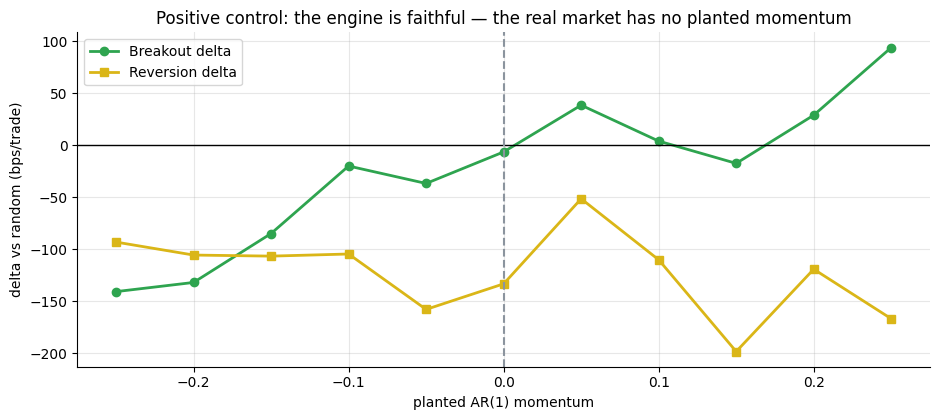

Engine confirmed: breakout alpha rises with +momentum; reversion alpha rises with -momentum.
Real tape result: both arms near zero because the tape has neither planted structure.


In [6]:
# Re-plot the positive control cleanly for the quant record.
moms2 = [-0.25,-0.20,-0.15,-0.10,-0.05, 0.0, 0.05,0.10,0.15,0.20,0.25]
bo2, rv2 = [], []
for m in moms2:
    bars, _ = data.synthetic_daily(n_days=3000, momentum=m, seed=128)
    for side, lst in [('breakout', bo2), ('reversion', rv2)]:
        ent = st.channel_entries(bars, side=side)
        if len(ent) < 5:
            lst.append(float('nan'))
            continue
        sig = st.summarize(st.run_trades(bars, ent, hold_days=20, cost_bps=0), 'ret_gross')['mean_bps']
        rnd = st.random_entries(bars, n=len(ent), seed=1)
        rand = st.summarize(st.run_trades(bars, rnd, hold_days=20, cost_bps=0), 'ret_gross')['mean_bps']
        lst.append(sig - rand)
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(moms2, bo2, 'o-', c=GREEN, lw=2, label='Breakout delta')
ax.plot(moms2, rv2, 's-', c=AMBER, lw=2, label='Reversion delta')
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted AR(1) momentum'); ax.set_ylabel('delta vs random (bps/trade)')
ax.set_title('Positive control: the engine is faithful — the real market has no planted momentum')
ax.legend(); plt.tight_layout(); plt.show()
print('Engine confirmed: breakout alpha rises with +momentum; reversion alpha rises with -momentum.')
print('Real tape result: both arms near zero because the tape has neither planted structure.')

The positive control confirms the machinery: the breakout alpha rises monotonically with planted momentum and the reversion alpha rises with planted mean-reversion. The real-tape result — both arms near zero vs random — is therefore a statement about the market (no exploitable structure at this horizon) not about the method.

Related studies worth comparing:
- **[Study 104 — Bollinger-Reversion](../../104-bollinger-reversion/)**: the Bollinger Band version — same framework, same result.
- **[Study 78 — Crossed-Wires](../../78-crossed-wires/)**: MACD daily — momentum filter with a more complex construction, same desk treatment.
- **[Study 21 — Fools-Gold](../../21-fools-gold/)**: the 50/200 daily golden cross — the moving-average momentum family.